# Trabajo práctico final Métodos numéricos
Maestría en Aplicaciones de Información Espacial (MAIE), I. Gulich
Estudiantes: Johanna Montoya y Franco Barrionuevo
Año: 2026

autor1_autor2_TPF
introducción: descripción del tema a abordar, qué modela, EDOs con su explicación respecto al modelo
metodología: metodo de euler, 
resultados: gráficos x vs t, diagrama de fases, e interpretación
conclusión (conclusión)
referencias

## Introducción

**Proceso de formación de la lluvia**


**Modelo depredador-presa aplicado a la interacción gotas de lluvia-precipitación**

Las nubes constituyen un complejo sistema nolinear dinámica con muchos grados de libertad e interacciones sobre un amplio rango de escalas espaciotemporales. A pesar de esta complejidad, algunos aspectos de su comportamientoa a nivel macro son predecibles aun sin considerar el total de la complejidad de este sistema dinámico. 

Un ejemplo de los comportamientos a macroescela, se corresponde al de la interacción entre las gotas de lluvia (*cloud droplets*) y la precipitación. Un primer modelo es el propuesto por Koren and Feingold (XXXX), el cual se caracteriza por tener la forma del sistema Lotka-Volterra de depredador-presa.

En el trabajo bajo el título "*Cloud–rain predator–preyinteractions:Analyzing some properties of the Koren–Feingold modeland introduction of a new species-competition bulk system with a Hopf bifurcation*", [Pujol and Jensen (2019)]() ...

que se pueden modelar mediante sistemas de ecuaciones no lne

## Metodología

In [14]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import pandas as pd
import math
import random

In [6]:
# Define Euler Solver in Python
def euler_solver_3d(f1, f2, f3, t0, tf, x10, x20, x30, h):
    '''
    f1: EDO f(x1, x2, x3); f2: EDO g(x1, x2, x3); f3: EDO h(x1, x2, x3)
    t0: Tiempo inicial; tf: Tiempo final
    x10, x20 y x30: Condiciones iniciales dimensiones 1, 2 y 3
    h: Timestep 
    '''

    # Define steps
    steps = int((tf-t0)/h)

    # Initialize variables & lists
    x1 = x10
    x2 = x20
    x3 = x30
    t = t0

    t_list = [t]
    x1_list = [x1]
    x2_list = [x2]
    x3_list = [x3]


    # For loop
    for i in range(steps):

        x1_old = x1
        x2_old = x2
        x3_old = x3

        x1 = x1_old + h*f1(t, x1_old, x2_old, x3_old)
        x2 = x2_old + h*f2(t, x1_old, x2_old, x3_old)
        x3 = x3_old + h*f3(t, x1_old, x2_old, x3_old)
        t = t + h

        t_list.append(t)
        x1_list.append(x1)
        x2_list.append(x2)
        x3_list.append(x3)

    return np.array(t_list), np.array(x1_list), np.array(x2_list), np.array(x3_list)

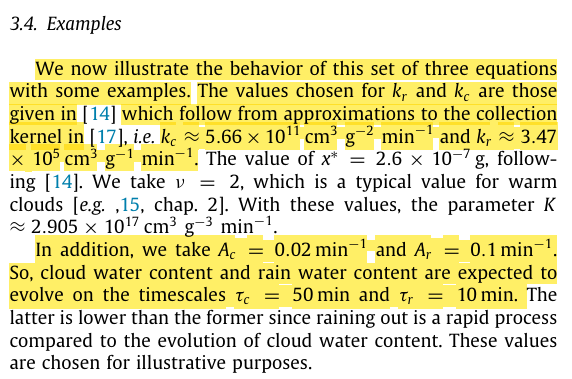

In [10]:
# Defino el paso de integración
H = 0.001

# Define parameter values
AC = 0.02 # min-1
AR = 0.1 # min-1
KR = 3.47e5 # cm3 g-1 min-1
KC = 5.66e11 # cm3 g-2 min-1
K = 2.905e17 # cm3 g-3 min-1

In [11]:
# Defino funciones para cada una de las EDOs del sistema
def dLcdt(t, Lc, Lr, Nd):
    bc = K * Nd**(-2)
    return AC*Lc - bc*Lc**4 - KR*Lc*Lr

def dLrdt(t, Lc, Lr, Nd):
    bc = K * Nd**(-2)
    return -AR*Lr + bc*Lc**4 + KR*Lc*Lr

def dNddt(t, Lc, Lr, Nd):
    return AC*(N0 - Nd) - (4/3)*KC*Lc**2 - KR*Lr*Nd

## Resultados

### Caso $N_{d}(0)$ < $N_{0}$

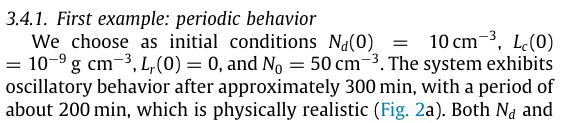

In [21]:
# Condiciones iniciales
ND0 = 10 # cm-3
LC0 = 10e-9 # cm-3
LR0 = 0
N0 = 50 # cm-3

In [15]:
# Resulvo el sistema empleando el método de euler
t, lc, lr, nd = euler_solver_3d(dLcdt, dLrdt, dNddt, 
                                0, 1000, 
                                LC0, LR0, N0, 
                                H)

c:\Users\win10\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


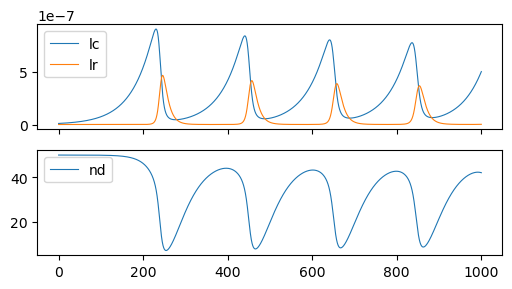

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(6, 3), sharex = True)

ax[0].plot(t, lc, lw = 0.8, label='lc')
ax[0].plot(t, lr, lw = 0.8, label='lr')

ax[1].plot(t, nd, lw = 0.8, label='nd')

ax[0].legend()
ax[1].legend()

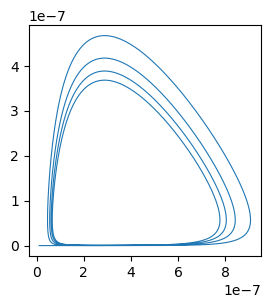

In [17]:
fig, ax = plt.subplots(figsize=(3, 3), sharex = True)

ax.plot(lc, lr, lw = 0.8, label='lc')

### Caso $N_{d}(0)$ > $N_{0}$

In [28]:
# Se redefine N0
N0 = ND0 # cm-3

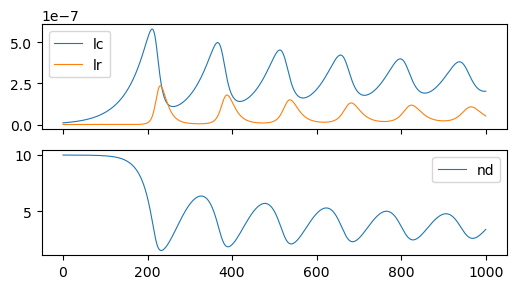

In [29]:
t, lc, lr, nd = euler_solver_3d(dLcdt, dLrdt, dNddt, 
                                0, 1000, 
                                LC0, LR0, ND0, 
                                H)

fig, ax = plt.subplots(2, 1, figsize=(6, 3), sharex = True)

ax[0].plot(t, lc, lw = 0.8, label='lc')
ax[0].plot(t, lr, lw = 0.8, label='lr')

ax[1].plot(t, nd, lw = 0.8, label='nd')

ax[0].legend()
ax[1].legend()

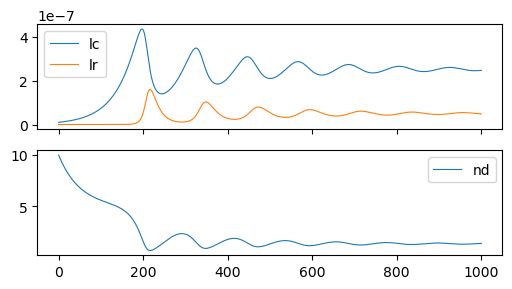

In [31]:
# Se redefine N0
N0 = ND0*0.5 # cm-3

t, lc, lr, nd = euler_solver_3d(dLcdt, dLrdt, dNddt, 
                                0, 1000, 
                                LC0, LR0, ND0, 
                                H)

fig, ax = plt.subplots(2, 1, figsize=(6, 3), sharex = True)

ax[0].plot(t, lc, lw = 0.8, label='lc')
ax[0].plot(t, lr, lw = 0.8, label='lr')

ax[1].plot(t, nd, lw = 0.8, label='nd')

ax[0].legend()
ax[1].legend()

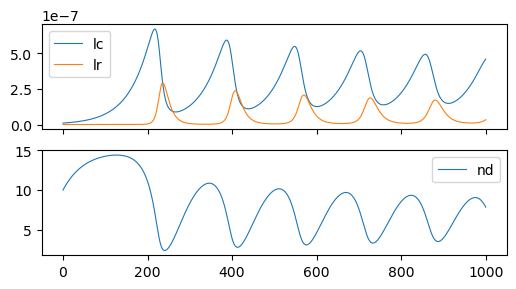

In [32]:
# Se redefine N0
N0 = ND0*1.5 # cm-3

t, lc, lr, nd = euler_solver_3d(dLcdt, dLrdt, dNddt, 
                                0, 1000, 
                                LC0, LR0, ND0, 
                                H)

fig, ax = plt.subplots(2, 1, figsize=(6, 3), sharex = True)

ax[0].plot(t, lc, lw = 0.8, label='lc')
ax[0].plot(t, lr, lw = 0.8, label='lr')

ax[1].plot(t, nd, lw = 0.8, label='nd')

ax[0].legend()
ax[1].legend()

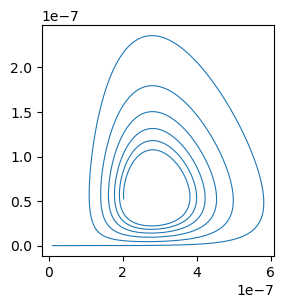

In [30]:
fig, ax = plt.subplots(figsize=(3, 3), sharex = True)

ax.plot(lc, lr, lw = 0.8, label='lc')

In [27]:
from scipy.optimize import fsolve

print(N0)

def equilibrium(X):
    Lc, Lr, Nd = X

    bc = K * Nd**(-2)

    return [
        AC*Lc - bc*Lc**4 - KR*Lc*Lr,
        -AR*Lr + bc*Lc**4 + KR*Lc*Lr,
        AC*(N0-Nd) - (4/3)*KC*Lc**2 - KR*Lr*Nd
    ]

eq = fsolve(equilibrium, [1e-6, 1e-6, N0])

print(eq)

5
[2.78677079e-07 5.58473654e-08 1.05111504e+00]


C:\Users\win10\AppData\Local\Temp\ipykernel_65108\2418923073.py:16: RuntimeWarning: The number of calls to function has reached maxfev = 800.
  eq = fsolve(equilibrium, [1e-6, 1e-6, N0])


Análisis de puntos críticos

$x_{1}^{e}$ = ($L_{c2}^{e}$, $L_{r2}^{e}$, $N_{d2}^{e}$) = (0,0, cte)

$x_{2}^{e}$ = ($L_{c2}^{e}$, $L_{r2}^{e}$, $N_{d2}^{e}$)


